# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import os
import sys
import pandas as pd
import numpy as np
import pickle

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X = fires_dt[['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']]
Y = fires_dt['area']

# Split the data
X_rest, X_test, Y_rest, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_validate, Y_train,  Y_validate = train_test_split(X_rest, Y_rest, test_size=0.2, random_state=42)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


num_cols = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
cat_cols = ['month', 'day']

pipe_num_simple = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('standardizer', StandardScaler())
])

preproc1 = ColumnTransformer([
    ('numeric', pipe_num_simple, num_cols),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

### Preproc 2

Create preproc2 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [6]:
from sklearn.preprocessing import PowerTransformer

pipe_num_yj = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('standardizer', StandardScaler()),
    ('transform', PowerTransformer(method='yeo-johnson'))
])
preproc2 = ColumnTransformer([
    ('numeric', pipe_num_yj, num_cols),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [7]:
# Pipeline A = preproc1 + baseline
from sklearn.linear_model import Ridge

pipe_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])
pipe_A.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardizer',
                                                     StandardScaler())]),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind', 'rain']),
                                   ('categorical',
                                    OneHotEncoder(handle_unknown='ignore'),
                                    ['month', 'day'])])),
  ('regressor', Ridge())],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric',
                                  Pipeline(step

In [8]:
# Pipeline B = preproc2 + baseline
pipe_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])


In [9]:
# Pipeline C = preproc1 + advanced model
from sklearn.ensemble import RandomForestRegressor
pipe_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor())
])
pipe_C.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardizer',
                                                     StandardScaler())]),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind', 'rain']),
                                   ('categorical',
                                    OneHotEncoder(handle_unknown='ignore'),
                                    ['month', 'day'])])),
  ('regressor', RandomForestRegressor())],
 'transform_input': None,
 'verbose': False,
 'preprocessing': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric',
                               

In [10]:
# Pipeline D = preproc2 + advanced model
pipe_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor())
])
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [11]:
from sklearn.model_selection import GridSearchCV

scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']
refit = 'neg_mean_squared_error'

param_grid_A = {
    'regressor__fit_intercept': [True, False]
    }
grid_A = GridSearchCV(
    estimator=pipe_A,
    param_grid=param_grid_A, 
    scoring=scoring,
    cv=5,
    refit='neg_mean_squared_error'
)

In [12]:
param_grid_B = {
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [True, False]
}

grid_B = GridSearchCV(
    estimator=pipe_B,
    param_grid=param_grid_B, 
    scoring=scoring,
    cv=5,
    refit='neg_mean_squared_error'
)

In [13]:
param_grid_C = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10]
}
grid_C = GridSearchCV(
    estimator=pipe_C,
    param_grid=param_grid_C,
    scoring=scoring,
    cv=5,
    refit='neg_mean_squared_error'
)


In [14]:
param_grid_D = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10]
}
grid_D = GridSearchCV(
    estimator=pipe_D,
    param_grid=param_grid_D,
    scoring=scoring,
    cv=5,
    refit='neg_mean_squared_error'
)

In [15]:
grid_A.fit(X_train, Y_train)
grid_B.fit(X_train, Y_train)
grid_C.fit(X_train, Y_train)
grid_D.fit(X_train, Y_train)


best_params_A = grid_A.best_params_

best_model_A = grid_A.best_estimator_

best_params_B = grid_B.best_params_


best_model_B = grid_B.best_estimator_

best_params_C = grid_C.best_params_

best_model_C = grid_C.best_estimator_

best_params_D = grid_D.best_params_

best_model_D = grid_D.best_estimator_

print("----A----")
print("Best model A:", best_params_A)
print("Best score", grid_A.best_score_)

print("----B----")
print("Best model B:", best_params_B) 
print("Best score", grid_B.best_score_)

print("----C----")
print("Best model C:", best_params_C)
print("Best score", grid_C.best_score_)

print("----D----")
print("Best model D:", best_params_D)
print("Best score", grid_D.best_score_)



----A----
Best model A: {'regressor__fit_intercept': False}
Best score -2675.152257892864
----B----
Best model B: {'regressor__fit_intercept': True, 'regressor__positive': False}
Best score -2635.7989239361045
----C----
Best model C: {'regressor__max_depth': 10, 'regressor__n_estimators': 100}
Best score -3492.7983435961714
----D----
Best model D: {'regressor__max_depth': 5, 'regressor__n_estimators': 100}
Best score -3429.4317283007576


# Evaluate

+ Which model has the best performance?


# Export

+ Save the best performing model to a pickle file.

### Evaluate:

ANS: Best performing model: Pipeline B <br>
Preprocessor: preproc2 (scaling + PowerTransformer) <br>
Regressor: Ridge() with fit_intercept=True


In [16]:
#Export
import pickle

# Save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_B, f)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

=== LOCAL EXPLANATION ===
Most important features for first test sample:


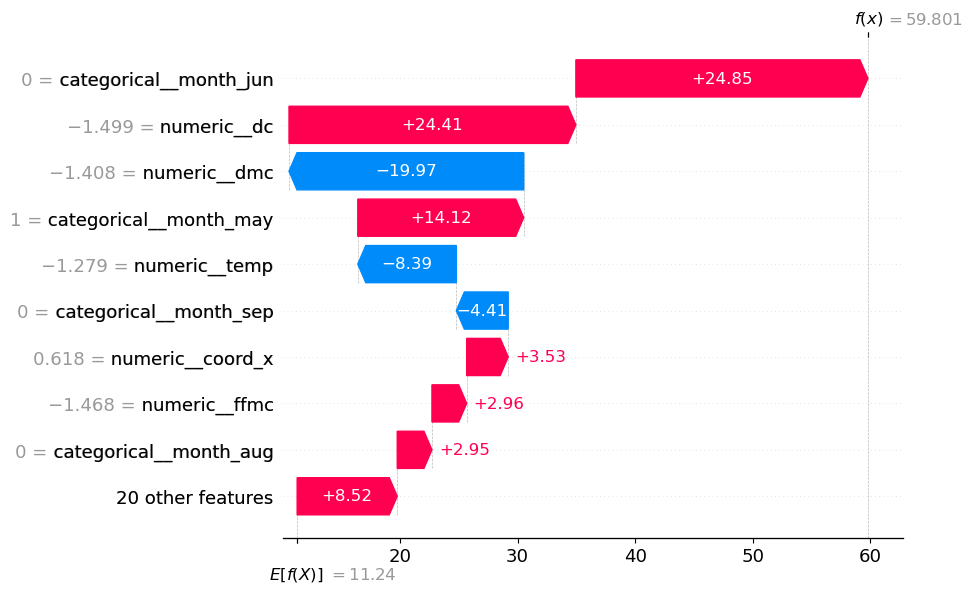


=== GLOBAL EXPLANATION ===
Overall feature importance across all samples:


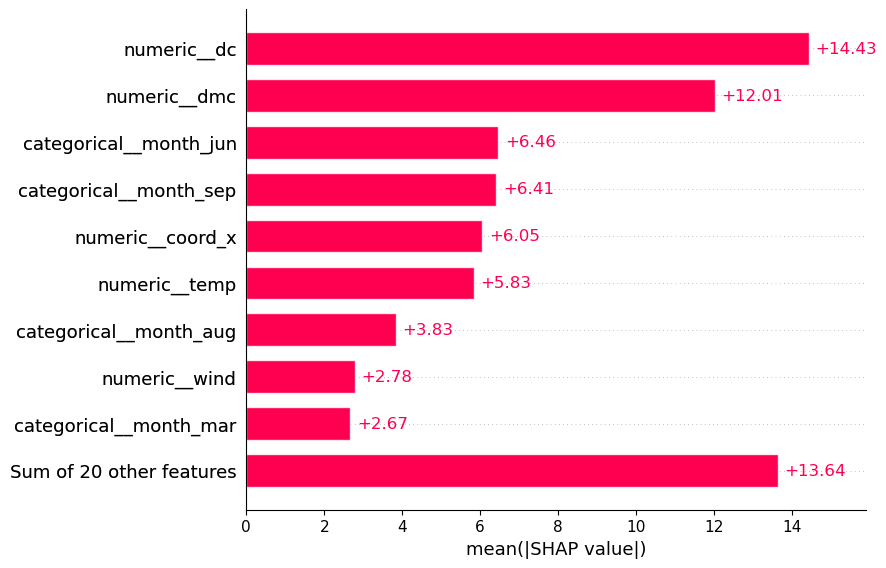

In [22]:
import shap

# 1. Local Explanation - Individual Prediction
print("=== LOCAL EXPLANATION ===")
print("Most important features for first test sample:")
shap.plots.waterfall(shap_values[0])

# 2. Global Explanation - Overall Feature Importance  
print("\n=== GLOBAL EXPLANATION ===")
print("Overall feature importance across all samples:")

# Use bar plot instead of beeswarm
shap.plots.bar(shap_values)



In [23]:
# Also show mean absolute SHAP values
feature_importance = pd.DataFrame({
    'feature': best_model_B.named_steps['preprocessing'].get_feature_names_out(),
    'importance': np.abs(shap_values.values).mean(0)
}).sort_values('importance', ascending=False)

print("\nTop 5 most important features:")
print(feature_importance.head(5))

print("\nBottom 5 least important features:")
print(feature_importance.tail(5))





Top 5 most important features:
                   feature  importance
4              numeric__dc   14.430552
3             numeric__dmc   12.014562
16  categorical__month_jun    6.461496
21  categorical__month_sep    6.411515
0         numeric__coord_x    6.052225

Bottom 5 least important features:
                   feature  importance
23    categorical__day_mon    0.176201
27    categorical__day_tue    0.143618
13  categorical__month_feb    0.071168
14  categorical__month_jan    0.058236
19  categorical__month_nov    0.000000


+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

Ans: <br>
categorical__day_mon, categorical__day_tue, categorical__month_feb, categorical__month_jan, categorical__month_nov

Why? <br>
These features have the lowest mean absolute SHAP values, indicating they contribute the least to the model's predictions. Removing these features could simplify the model without significantly impacting its performance.
Testing?
- Create a new pipeline without these low-importance features

- Retrain the model and compare performance on validation set

- Use the same evaluation metric (neg_mean_squared_error)

- If performance is similar or better, the features weren't helpful



## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.